# RBF Feature Expansion + Ridge Regression

## What it does
Maps the original feature matrix into a **random Fourier feature space** that approximates the RBF
(Radial Basis Function / Gaussian) kernel, then fits **Ridge regression** on the expanded features.
The result is a scalable non-linear model that can capture interactions the original linear features miss.

### The two-stage pipeline
1. **RBFSampler** — draws `n_components` random frequency vectors from a Gaussian and maps each
   observation `x` to:
   $$\phi(x) = \sqrt{\tfrac{2}{m}}\,[\cos(\omega_1^\top x + b_1),\ldots,\cos(\omega_m^\top x + b_m)]$$
   so that $\phi(x)^\top \phi(x') \approx \exp(-\gamma\|x-x'\|^2)$ (the RBF kernel).
2. **Ridge regression** on the expanded features — regularizes the high-dimensional mapping.

## Parameters
| Parameter | Effect |
|---|---|
| `gamma` | RBF bandwidth: high gamma = narrow kernel = local model; low = global smoothing |
| `n_components` | Number of random Fourier features: more → better approximation, more risk of overfit |
| `ridge_alpha` | Ridge penalty: shrinks coefficients in the expanded space |

## When to use it
- You suspect non-linear interactions between predictors but want a tractable (non-tree) model
- Dataset is too large for exact KernelRidge (which is O(n²)); RBFSampler scales linearly
- You want a non-linear baseline alongside Ridge, Lasso, PLS, and GBR

## Data format
Same panel format as all other supervised notebooks: `DATE_COL`, `ID_COL`, `TARGET_COL`,
remaining numeric columns = features.

## Configuration

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,     # Required for RBFSampler to work well
    # --- RBFSampler grid ---
    'N_COMPONENTS_GRID':  [50, 100, 200, 500],   # random Fourier features
    'GAMMA_GRID':         [0.01, 0.1, 1.0, 10.0],
    # --- Ridge alpha (regularization on expanded features) ---
    'RIDGE_ALPHAS':       [0.01, 0.1, 1.0, 10.0, 100.0],
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         'results',
    'RBF_RANDOM_STATE':   42,
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  N_COMPONENTS_GRID: [50, 100, 200, 500]
  GAMMA_GRID: [0.01, 0.1, 1.0, 10.0]
  RIDGE_ALPHAS: [0.01, 0.1, 1.0, 10.0, 100.0]
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results
  RBF_RANDOM_STATE: 42


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys, warnings, os, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import Ridge

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))
from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df, date_col=CONFIG['DATE_COL'],
    train_years=CONFIG['TRAIN_YEARS'], val_years=CONFIG['VAL_YEARS'],
)
print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']}   — {split_info['val_end']}    ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']}   — {split_info['test_end']}    ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945   — 1956    (709 obs)
Test       : 1957   — 2022    (77,548 obs)


## Step 2 — Prepare Features & Standardize

Standardization is **required** before RBFSampler: the gamma parameter assumes features are on
a comparable scale when computing Euclidean distances.

In [4]:
X, y, feature_cols = prepare_panel_data(
    df, target_col=CONFIG['TARGET_COL'],
    exclude_cols=[CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value=CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)
    print('Features standardized (fit on training data only).')

y_train_mean = float(y_train.mean())
print(f'Features      : {len(feature_cols)}')
print(f'Train obs     : {X_train.shape[0]:,}')
print(f'Training mean : {y_train_mean:.6f}')

Features standardized (fit on training data only).
Features      : 209
Train obs     : 884
Training mean : 0.007120


## Step 3 — Grid Search: (n_components, gamma) with fixed Ridge alpha

For efficiency, we first search (n_components, gamma) with the median Ridge alpha, then
fine-tune Ridge alpha at the best RBF configuration.
Best hyperparameters selected by **validation OOS R²** only.

In [5]:
# Stage 1: grid search over (n_components, gamma) with middle Ridge alpha
mid_alpha = CONFIG['RIDGE_ALPHAS'][len(CONFIG['RIDGE_ALPHAS']) // 2]
print(f'Stage 1: searching (n_components, gamma) with Ridge alpha={mid_alpha}')
print('=' * 65)

stage1_results = []
for n_comp in CONFIG['N_COMPONENTS_GRID']:
    for gamma in CONFIG['GAMMA_GRID']:
        rbf = RBFSampler(n_components=n_comp, gamma=gamma,
                         random_state=CONFIG['RBF_RANDOM_STATE'])
        X_tr_rbf  = rbf.fit_transform(X_train)
        X_val_rbf = rbf.transform(X_val)

        ridge = Ridge(alpha=mid_alpha)
        ridge.fit(X_tr_rbf, y_train)
        oos_r2 = compute_oos_r2(y_val.values, ridge.predict(X_val_rbf), y_train_mean)

        stage1_results.append({'n_components': n_comp, 'gamma': gamma,
                                'oos_r2_val': oos_r2})
        print(f'  n_comp={n_comp:4d}  gamma={gamma:.3f}  Val OOS R²={oos_r2*100:+.4f}%')

best_s1 = max(stage1_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest Stage 1: n_components={best_s1['n_components']}, gamma={best_s1['gamma']}")

Stage 1: searching (n_components, gamma) with Ridge alpha=1.0
  n_comp=  50  gamma=0.010  Val OOS R²=-78.5761%
  n_comp=  50  gamma=0.100  Val OOS R²=-7.7994%
  n_comp=  50  gamma=1.000  Val OOS R²=-14.3911%


  n_comp=  50  gamma=10.000  Val OOS R²=-10.2166%


  n_comp= 100  gamma=0.010  Val OOS R²=-76.0603%
  n_comp= 100  gamma=0.100  Val OOS R²=-27.0833%
  n_comp= 100  gamma=1.000  Val OOS R²=-21.2434%
  n_comp= 100  gamma=10.000  Val OOS R²=-25.8976%
  n_comp= 200  gamma=0.010  Val OOS R²=-38.4051%
  n_comp= 200  gamma=0.100  Val OOS R²=-40.0451%
  n_comp= 200  gamma=1.000  Val OOS R²=-46.6772%
  n_comp= 200  gamma=10.000  Val OOS R²=-48.7189%
  n_comp= 500  gamma=0.010  Val OOS R²=-18.5843%
  n_comp= 500  gamma=0.100  Val OOS R²=-45.2949%


  n_comp= 500  gamma=1.000  Val OOS R²=-54.4450%


  n_comp= 500  gamma=10.000  Val OOS R²=-48.4595%

Best Stage 1: n_components=50, gamma=0.1


In [6]:
# Stage 2: tune Ridge alpha at best (n_components, gamma)
print(f"\nStage 2: tuning Ridge alpha at n_components={best_s1['n_components']}, gamma={best_s1['gamma']}")
print('=' * 65)

rbf_best = RBFSampler(n_components=best_s1['n_components'], gamma=best_s1['gamma'],
                      random_state=CONFIG['RBF_RANDOM_STATE'])
X_tr_rbf  = rbf_best.fit_transform(X_train)
X_val_rbf = rbf_best.transform(X_val)

stage2_results = []
for alpha in CONFIG['RIDGE_ALPHAS']:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_tr_rbf, y_train)
    oos_r2 = compute_oos_r2(y_val.values, ridge.predict(X_val_rbf), y_train_mean)
    stage2_results.append({'alpha': alpha, 'oos_r2_val': oos_r2, 'model': ridge})
    print(f'  alpha={alpha:.4f}  Val OOS R²={oos_r2*100:+.4f}%')

best_s2 = max(stage2_results, key=lambda r: r['oos_r2_val'])
best_ridge = best_s2['model']
print(f"\nFinal best: n_components={best_s1['n_components']}, gamma={best_s1['gamma']}, alpha={best_s2['alpha']}")
print(f"Final Val OOS R²: {best_s2['oos_r2_val']*100:+.4f}%")


Stage 2: tuning Ridge alpha at n_components=50, gamma=0.1
  alpha=0.0100  Val OOS R²=-9.1128%
  alpha=0.1000  Val OOS R²=-8.9819%
  alpha=1.0000  Val OOS R²=-7.7994%
  alpha=10.0000  Val OOS R²=-2.3371%
  alpha=100.0000  Val OOS R²=+0.4304%

Final best: n_components=50, gamma=0.1, alpha=100.0
Final Val OOS R²: +0.4304%


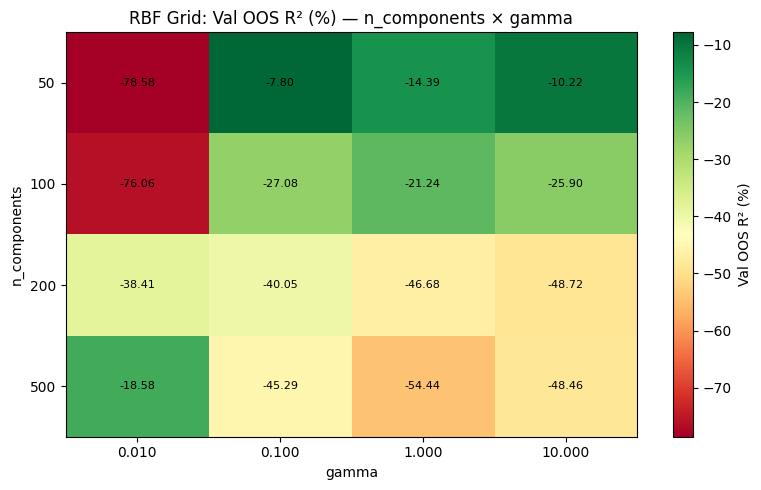

In [7]:
# Heatmap: (n_components × gamma)
s1_df  = pd.DataFrame(stage1_results)
pivot  = s1_df.pivot(index='n_components', columns='gamma', values='oos_r2_val') * 100

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{v:.3f}' for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('gamma')
ax.set_ylabel('n_components')
ax.set_title('RBF Grid: Val OOS R² (%) — n_components × gamma')
for i, j in itertools.product(range(len(pivot.index)), range(len(pivot.columns))):
    ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Val OOS R² (%)')
plt.tight_layout()
plt.show()

## Step 4 — Final Evaluation on All Splits

In [8]:
X_test_rbf = rbf_best.transform(X_test)

preds = {
    'train': best_ridge.predict(X_tr_rbf),
    'val':   best_ridge.predict(X_val_rbf),
    'test':  best_ridge.predict(X_test_rbf),
}

metrics = evaluate_splits(
    y_train, preds['train'], y_val, preds['val'], y_test, preds['test'],
    train_mean=y_train_mean,
)

print('RBF REGRESSION — BEST MODEL EVALUATION')
print('=' * 55)
print(f"  n_components   : {best_s1['n_components']}")
print(f"  gamma          : {best_s1['gamma']}")
print(f"  Ridge alpha    : {best_s2['alpha']}")
print()
print(f"  Train R²       : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 55)

RBF REGRESSION — BEST MODEL EVALUATION
  n_components   : 50
  gamma          : 0.1
  Ridge alpha    : 100.0

  Train R²       : +1.5637%
  Val R²         : -1.3479%
  Test R²        : -0.6177%

  OOS R² Val     : +0.4304%
  OOS R² Test    : -0.0566%


## Step 5 — Portfolio Formation & Sharpe Ratio

RBF LONG-SHORT PORTFOLIO
  Months         : 552
  Mean monthly   : -0.1508%
  Std monthly    : 4.7066%
  Sharpe (ann.)  : -0.1110


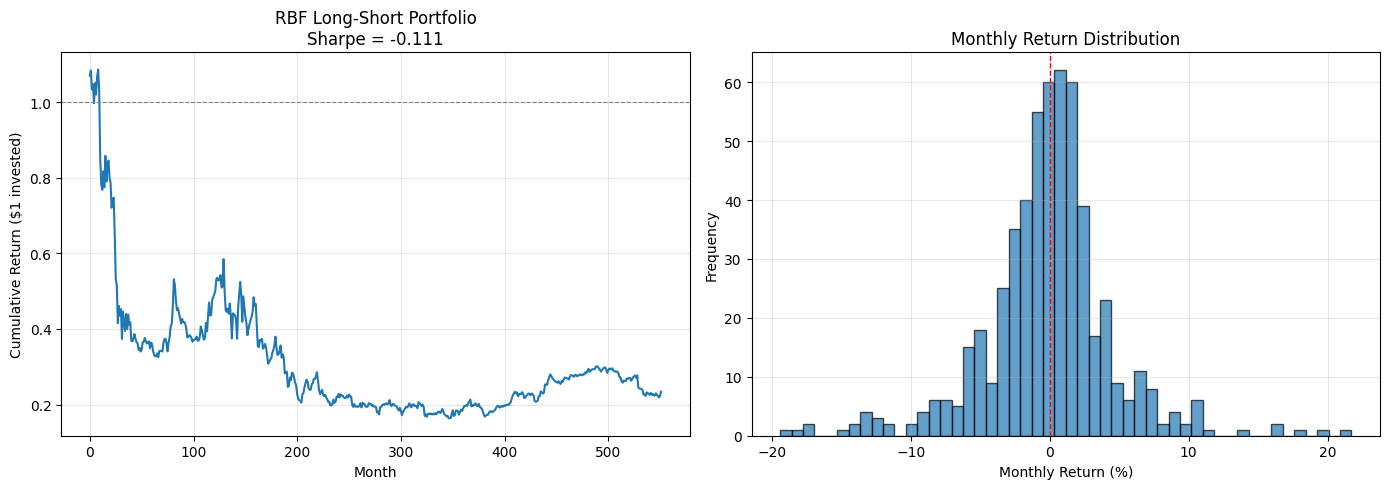

In [9]:
test_df_base = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df_base['predicted_ret'] = preds['test']
test_df_base = test_df_base.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df_base, date_col=CONFIG['DATE_COL'],
    pred_col='predicted_ret', ret_col='actual_ret',
    n_deciles=CONFIG['N_DECILES'],
)
port_stats = portfolio_summary(port_returns)

print('RBF LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months         : {port_stats['n_periods']}")
print(f"  Mean monthly   : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly    : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)  : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

cumulative = (1 + port_returns).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set(xlabel='Month', ylabel='Cumulative Return ($1 invested)',
            title=f'RBF Long-Short Portfolio\nSharpe = {port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set(xlabel='Monthly Return (%)', ylabel='Frequency', title='Monthly Return Distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Save Results

In [10]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name    = 'RBF Regression',
        description   = 'RBFSampler (Random Fourier Features) + Ridge Regression',
        tuning_params = f"n_components={best_s1['n_components']}, gamma={best_s1['gamma']}, ridge_alpha={best_s2['alpha']}",
        metrics       = metrics,
        portfolio_stats = port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'rbf_regression',
    )
    path = save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'rbf_summary.csv')
    print(f'Saved: {path}')
    path = save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'rbf_portfolios.csv')
    print(f'Saved: {path}')
else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/rbf_summary.csv
Saved: results/rbf_portfolios.csv
